# Red Neuronal - Clasificacion de Colores

Entrenamiento de una red neuronal con datos de frecuencias (R, G, B, C) y altura (h)
para clasificar colores:

- ROJO -> Manzana
- NARANJA -> Naranja
- MORADO -> Uva

Integrantes:

Hector Gerardo Quiñones Romo - 2132258

Diego Montelongo García - 2095700

Jesús Gael Garcia Iracheta - 2173941

Lizbeth Aguila Carvajal - 2092193

María Alejandra López Hernández - 2177935

HORA: N4

In [11]:
from google.colab import drive
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

In [12]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# Buscar el archivo en todo Drive
print('Buscando archivo en Drive...')
for root, dirs, archivos in os.walk('/content/drive/MyDrive'):
    for archivo in archivos:
        if 'Frecuencias' in archivo or 'frecuencias' in archivo:
            print(os.path.join(root, archivo))
print('Busqueda terminada.')

Buscando archivo en Drive...
/content/drive/MyDrive/Frecuencias y alturas 5.csv
Busqueda terminada.


In [14]:
# Pega aqui la ruta que arrojo la celda anterior
csv_path = '/content/drive/MyDrive/Frecuencias y alturas 5.csv'

print(f'Ruta del CSV: {csv_path}')

Ruta del CSV: /content/drive/MyDrive/Frecuencias y alturas 5.csv


In [15]:
df = pd.read_csv(csv_path)

# Renombrar columnas
df.columns = ['R_Hz', 'G_Hz', 'B_Hz', 'C_Hz', 'Altura_cm', 'COLOR']

# Eliminar filas con NaN
df = df.dropna().reset_index(drop=True)

print(f'Total de muestras: {len(df)}')
print(f'\nDistribucion de clases:')
print(df['COLOR'].value_counts())
print()
df.head(10)

Total de muestras: 45

Distribucion de clases:
COLOR
ROJO       15
NARANJA    15
MORADO     15
Name: count, dtype: int64



,R_Hz,G_Hz,B_Hz,C_Hz,Altura_cm,COLOR
0,6799,3473,3589,13894,4.73,ROJO
1,6802,3472,3583,13907,4.97,ROJO
2,6798,3463,3591,13898,4.85,ROJO
3,6794,3471,3583,13893,5.15,ROJO
4,6795,3466,3586,13904,4.83,ROJO
5,6801,3467,3594,13901,5.53,ROJO
6,6799,3475,3592,13895,5.43,ROJO
7,6798,3477,3593,13902,5.50,ROJO
8,6795,3464,3584,13904,4.89,ROJO
9,6794,3475,3596,13902,4.89,ROJO


In [16]:
num_cols = ['R_Hz', 'G_Hz', 'B_Hz', 'C_Hz', 'Altura_cm']

X = df[num_cols].values
y_raw = df['COLOR'].values

le = LabelEncoder()
y = le.fit_transform(y_raw)
n_clases = len(le.classes_)

print('Clases codificadas:', dict(zip(le.classes_, le.transform(le.classes_))))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras')

Clases codificadas: {'MORADO': np.int64(0), 'NARANJA': np.int64(1), 'ROJO': np.int64(2)}

Train: 36 muestras | Test: 9 muestras


In [17]:
tf.random.set_seed(42)

modelo = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(n_clases, activation='softmax')
], name='ClasificadorColores')

modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo.summary()

Model: "ClasificadorColores"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,427 (13.39 KB)

 Trainable params: 3,235 (12.64 KB)

 Non-trainable params: 192 (768.00 B)

In [18]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
)

history = modelo.fit(
    X_train, y_train,
    epochs=200,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.3214 - loss: 1.1734 - val_accuracy: 0.6250 - val_loss: 1.0307
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4286 - loss: 0.9288 - val_accuracy: 0.6250 - val_loss: 0.9872
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6429 - loss: 0.7906 - val_accuracy: 0.6250 - val_loss: 0.9433
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8214 - loss: 0.6542 - val_accuracy: 0.8750 - val_loss: 0.9045
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7500 - loss: 0.6285 - val_accuracy: 0.8750 - val_loss: 0.8659
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8214 - loss: 0.5399 - val_accuracy: 0.8750 - val_loss: 0.8314
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9286 - loss: 0.4674 - val_accuracy: 0.8750 - val_loss: 0.7977
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9286 - loss: 0.4166 - val_accuracy: 0.8750 - val_loss

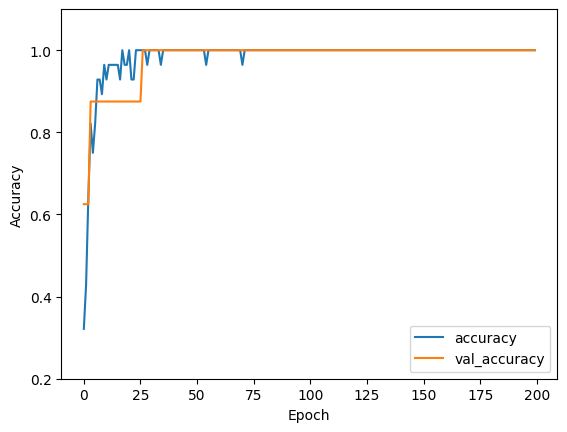

1/1 - 0s - 215ms/step - accuracy: 1.0000 - loss: 2.1726e-04

Precision final en validacion: 100.00%


In [19]:
plt.plot(history.history['accuracy'],     label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.2, 1.1])
plt.legend(loc='lower right')
plt.show()

test_loss, test_acc = modelo.evaluate(X_test, y_test, verbose=2)

print(f'\nPrecision final en validacion: {test_acc*100:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Reporte de clasificacion:
              precision    recall  f1-score   support

      MORADO       1.00      1.00      1.00         3
     NARANJA       1.00      1.00      1.00         3
        ROJO       1.00      1.00      1.00         3

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



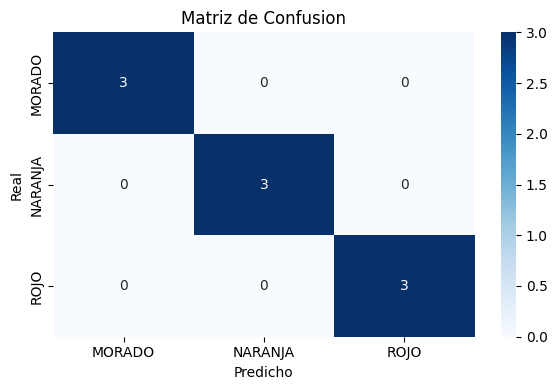

In [20]:
y_pred = np.argmax(modelo.predict(X_test), axis=1)

print('Reporte de clasificacion:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusion')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

In [21]:
FRUTAS = {
    'ROJO':    'Manzana',
    'NARANJA': 'Naranja',
    'MORADO':  'Uva',
}

def predecir_fruta(R_Hz, G_Hz, B_Hz, C_Hz, Altura_cm):
    entrada = np.array([[R_Hz, G_Hz, B_Hz, C_Hz, Altura_cm]], dtype=float)
    entrada_norm = scaler.transform(entrada)
    probs = modelo.predict(entrada_norm, verbose=0)[0]
    idx_pred = np.argmax(probs)
    color_pred = le.inverse_transform([idx_pred])[0]
    confianza = probs[idx_pred] * 100

    print(f'Color detectado : {color_pred}')
    print(f'Confianza       : {confianza:.1f}%')
    print(f'Resultado       : {FRUTAS[color_pred]}')
    return FRUTAS[color_pred]

print('=' * 40)
print('PRUEBA 1 - Valores tipicos de ROJO')
predecir_fruta(6799, 3473, 3589, 13894, 4.73)

print('\n' + '=' * 40)
print('PRUEBA 2 - Valores tipicos de NARANJA')
predecir_fruta(9855, 4678, 4339, 18697, 5.21)

print('\n' + '=' * 40)
print('PRUEBA 3 - Valores tipicos de MORADO')
predecir_fruta(5126, 3262, 3387, 12087, 5.83)

PRUEBA 1 - Valores tipicos de ROJO
Color detectado : ROJO
Confianza       : 100.0%
Resultado       : Manzana

PRUEBA 2 - Valores tipicos de NARANJA
Color detectado : NARANJA
Confianza       : 100.0%
Resultado       : Naranja

PRUEBA 3 - Valores tipicos de MORADO
Color detectado : MORADO
Confianza       : 100.0%
Resultado       : Uva


'Uva'

In [22]:
nombre_modelo = 'modelo_colores.keras'
modelo.save(nombre_modelo)

joblib.dump(scaler, 'scaler_colores.pkl')
joblib.dump(le,     'label_encoder_colores.pkl')

files.download(nombre_modelo)
files.download('scaler_colores.pkl')
files.download('label_encoder_colores.pkl')

print(f'Precision final en validacion: {test_acc*100:.2f}%')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Precision final en validacion: 100.00%
